In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install neuraloperator -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 4.3 MB/s eta 0:00:00


In [3]:
import torch
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.data.datasets import load_darcy_flow_small

device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=1000, batch_size=32,
    n_tests=[100, 50], test_resolutions=[16, 32], test_batch_sizes=[32, 32],
)
data_processor = data_processor.to(device)

Loading test db for resolution 16 with 100 samples 
Loading test db for resolution 32 with 50 samples 


input x: torch.Size([32, 1, 16, 16])  target y: torch.Size([32, 1, 16, 16])


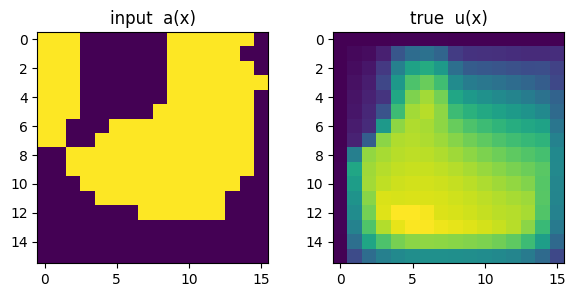

In [4]:
import matplotlib.pyplot as plt
batch = next(iter(train_loader))
print("input x:", batch['x'].shape, " target y:", batch['y'].shape)
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(batch['x'][0, 0]); ax[0].set_title("input  a(x)")
ax[1].imshow(batch['y'][0, 0]); ax[1].set_title("true  u(x)")
plt.show()

In [5]:
model = FNO(n_modes=(16, 16), in_channels=1, out_channels=1,
            hidden_channels=64, n_layers=4).to(device)
print("params:", sum(p.numel() for p in model.parameters()))

params: 2410177


In [6]:
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)
optimizer = torch.optim.Adam(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

trainer = Trainer(model=model, n_epochs=30, device=device,
                  data_processor=data_processor, eval_interval=3, verbose=True)
trainer.train(train_loader=train_loader, test_loaders=test_loaders,
              optimizer=optimizer, scheduler=scheduler, regularizer=False,
              training_loss=h1loss, eval_losses={'h1': h1loss, 'l2': l2loss})

Training on 1000 samples
Testing on [50, 50] samples         on resolutions [16, 32].


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1787: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)


Raw outputs of shape torch.Size([32, 1, 16, 16])


/usr/local/lib/python3.12/dist-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=1.77, avg_loss=0.7111, train_err=22.2210


/usr/local/lib/python3.12/dist-packages/neuralop/training/trainer.py:581: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)


Eval: 16_h1=0.3732, 16_l2=0.2593, 32_h1=0.5089, 32_l2=0.2732
[3] time=0.58, avg_loss=0.1909, train_err=5.9653
Eval: 16_h1=0.2559, 16_l2=0.1877, 32_h1=0.4038, 32_l2=0.2002
[6] time=0.53, avg_loss=0.1798, train_err=5.6201
Eval: 16_h1=0.2062, 16_l2=0.1393, 32_h1=0.4209, 32_l2=0.1778
[9] time=0.55, avg_loss=0.1659, train_err=5.1830
Eval: 16_h1=0.2580, 16_l2=0.1874, 32_h1=0.3967, 32_l2=0.2014
[12] time=0.56, avg_loss=0.1486, train_err=4.6445
Eval: 16_h1=0.2021, 16_l2=0.1167, 32_h1=0.4115, 32_l2=0.1487
[15] time=0.53, avg_loss=0.1466, train_err=4.5828
Eval: 16_h1=0.2305, 16_l2=0.1406, 32_h1=0.3744, 32_l2=0.1550
[18] time=0.55, avg_loss=0.1122, train_err=3.5072
Eval: 16_h1=0.1855, 16_l2=0.1096, 32_h1=0.3922, 32_l2=0.1456
[21] time=0.55, avg_loss=0.1047, train_err=3.2733
Eval: 16_h1=0.1894, 16_l2=0.1120, 32_h1=0.3861, 32_l2=0.1427
[24] time=0.55, avg_loss=0.0562, train_err=1.7578
Eval: 16_h1=0.1789, 16_l2=0.0991, 32_h1=0.3973, 32_l2=0.1360
[27] time=0.54, avg_loss=0.0429, train_err=1.3413
Eval

{'train_err': 1.1775828022509813,
 'avg_loss': 0.0376826496720314,
 'avg_lasso_loss': None,
 'epoch_train_time': 0.5560460179999609}

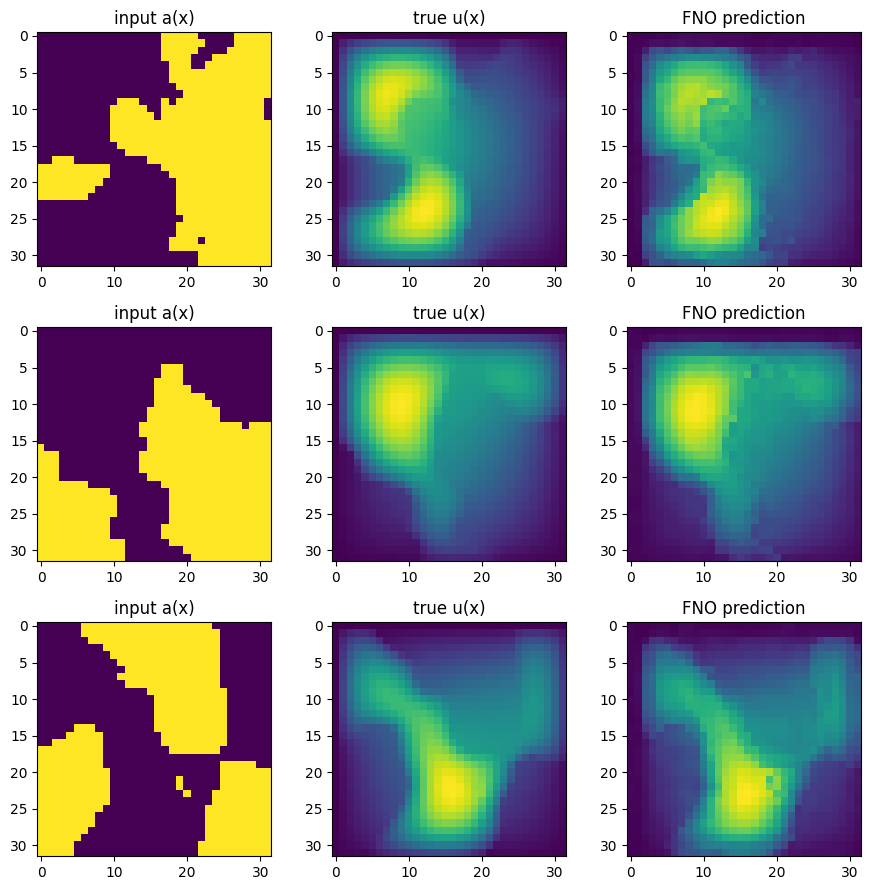

In [7]:
model.eval(); data_processor.eval()
batch = next(iter(test_loaders[32]))          # 32x32, unseen resolution
batch = data_processor.preprocess(batch)
with torch.no_grad():
    out = model(batch['x'])
out, batch = data_processor.postprocess(out, batch)

x, y, out = batch['x'].cpu(), batch['y'].cpu(), out.detach().cpu()
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    axes[i,0].imshow(x[i,0]);   axes[i,0].set_title("input a(x)")
    axes[i,1].imshow(y[i,0]);   axes[i,1].set_title("true u(x)")
    axes[i,2].imshow(out[i,0]); axes[i,2].set_title("FNO prediction")
plt.tight_layout(); plt.show()